# Лабораторна робота 4. Імовірнісний підхід до машинного навчання. Байєсівська класифікатор

### Дисципліна: Розпізнавання образів та комп'ютерний зір
### Група: КІ-22-1
### Студент: Савченко Андрій Олександрович

## Завдання для самостійної роботи

### 1. Реалізувати наївний байєсівський класифікатор для свого варіанта (І завдання).
### 2. Реалізувати байєсівський класифікатор, попередньо змоделювавши дані згідно параметри кластерів у відповідності до свого варіанта (ІІ завдання).
 - ### Змінити знак коефіцієнта кореляції одного з кластерів. Повторити експеримент з класифікації. Що відбулося? вивести результати і прокоментувати
 - ### Модифікувати код на випадок трьох кластерів. Змоделювати відповідні дані і візуалізувати результати. ПРодемонструвати працездатність класифікатора.
### 3. Дати відповіді на контрольні запитання.
### 4. Відправити результати роботи у файлі lab_4_StudentLastName.ipynb до віддаленого репозиторію на GіtHub.

## Варіанти індивідульних завдань

І завдання
<br> Варіант 9:
<br> x_train_9:
<br> [[29 28]
<br>  [48  9]
<br>  [ 8 43]
<br>  [14 13]
<br>  [12 18]
<br>  [16 47]
<br>  [21 36]
<br>  [11 45]
<br>  [34 22]
<br>  [42 17]]
<br> y_train_9:
<br> [-1  1 -1 -1  1 -1  1 -1  1  1]

Predicted: [ 1  1 -1  1 -1 -1 -1 -1  1  1]
True: [-1  1 -1 -1  1 -1  1 -1  1  1]


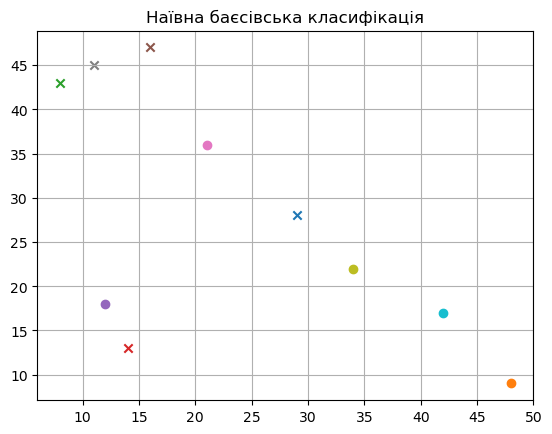

In [2]:
import numpy as np
import matplotlib.pyplot as plt

x_train = np.array([
 [29,28],[48,9],[8,43],[14,13],[12,18],
 [16,47],[21,36],[11,45],[34,22],[42,17]
])

y_train = np.array([-1,1,-1,-1,1,-1,1,-1,1,1])

x_pos = x_train[y_train == 1]
x_neg = x_train[y_train == -1]

def stats(x):
    return np.mean(x, axis=0), np.var(x, axis=0)

mu_pos, var_pos = stats(x_pos)
mu_neg, var_neg = stats(x_neg)

# Gaussian PDF
def gaussian(x, mu, var):
    return (1 / np.sqrt(2*np.pi*var)) * np.exp(-(x - mu)**2 / (2*var))

# Класифікація
def predict(x):
    p_pos = np.prod(gaussian(x, mu_pos, var_pos))
    p_neg = np.prod(gaussian(x, mu_neg, var_neg))
    
    return 1 if p_pos > p_neg else -1

y_pred = np.array([predict(x) for x in x_train])

print("Predicted:", y_pred)
print("True:", y_train)

for i in range(len(x_train)):
    if y_train[i] == 1:
        plt.scatter(x_train[i][0], x_train[i][1], marker='o')
    else:
        plt.scatter(x_train[i][0], x_train[i][1], marker='x')

plt.title("Наївна баєсівська класифікація")
plt.grid(True)
plt.show()

ІІ завдання
$$9. \rho_1 = 0.7, \sigma^2_{x_1} = 1.9, \mu_{x_1} = [2, 4]^T, \sigma^2_{y_1} = 0.8, \mu_{y_1} = [2, 4]^T$$

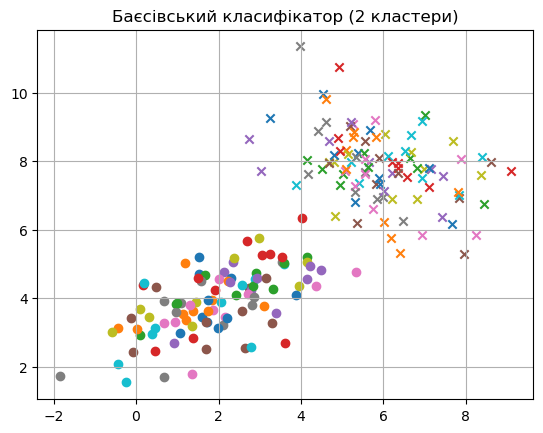

In [4]:
import numpy as np
import matplotlib.pyplot as plt

mu1 = np.array([2, 4])
sigma_x1 = 1.9
sigma_y1 = 0.8
rho1 = 0.7

cov1 = [[sigma_x1, rho1],
        [rho1, sigma_y1]]

mu2 = np.array([6, 8])
cov2 = [[1.5, -0.5],
        [-0.5, 1.0]]

X1 = np.random.multivariate_normal(mu1, cov1, 100)
X2 = np.random.multivariate_normal(mu2, cov2, 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

def gaussian_multivariate(x, mu, cov):
    d = len(mu)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    
    return np.exp(-0.5 * (x - mu).T @ inv @ (x - mu)) / np.sqrt((2*np.pi)**d * det)

def predict(x):
    p1 = gaussian_multivariate(x, mu1, cov1)
    p2 = gaussian_multivariate(x, mu2, cov2)
    return 0 if p1 > p2 else 1

y_pred = np.array([predict(x) for x in X])

for i in range(len(X)):
    if y_pred[i] == 0:
        plt.scatter(X[i][0], X[i][1], marker='o')
    else:
        plt.scatter(X[i][0], X[i][1], marker='x')

plt.title("Баєсівський класифікатор (2 кластери)")
plt.grid(True)
plt.show()

Зміна знаку кореляції

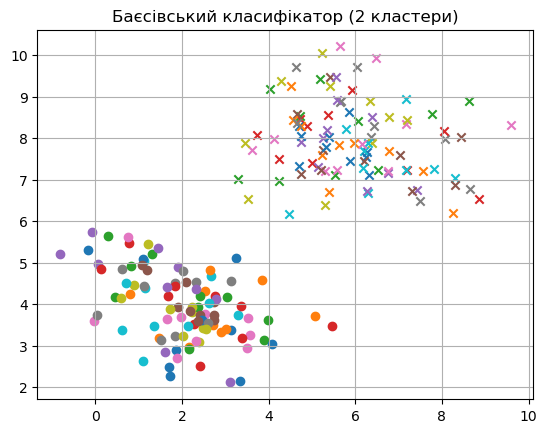

In [6]:
import numpy as np
import matplotlib.pyplot as plt

mu1 = np.array([2, 4])
sigma_x1 = 1.9
sigma_y1 = 0.8

cov1 = [[sigma_x1, -0.7],
        [-0.7, sigma_y1]]

mu2 = np.array([6, 8])
cov2 = [[1.5, -0.5],
        [-0.5, 1.0]]

X1 = np.random.multivariate_normal(mu1, cov1, 100)
X2 = np.random.multivariate_normal(mu2, cov2, 100)

X = np.vstack([X1, X2])
y = np.array([0]*100 + [1]*100)

def gaussian_multivariate(x, mu, cov):
    d = len(mu)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    
    return np.exp(-0.5 * (x - mu).T @ inv @ (x - mu)) / np.sqrt((2*np.pi)**d * det)

def predict(x):
    p1 = gaussian_multivariate(x, mu1, cov1)
    p2 = gaussian_multivariate(x, mu2, cov2)
    return 0 if p1 > p2 else 1

y_pred = np.array([predict(x) for x in X])

for i in range(len(X)):
    if y_pred[i] == 0:
        plt.scatter(X[i][0], X[i][1], marker='o')
    else:
        plt.scatter(X[i][0], X[i][1], marker='x')

plt.title("Баєсівський класифікатор (2 кластери)")
plt.grid(True)
plt.show()

3 кластери

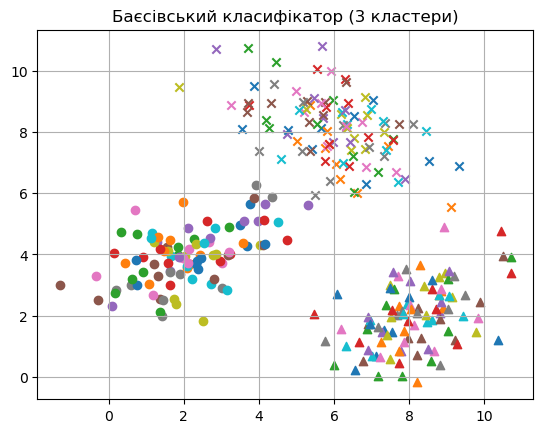

In [8]:
import numpy as np
import matplotlib.pyplot as plt

mu1 = np.array([2, 4])
sigma_x1 = 1.9
sigma_y1 = 0.8
rho1 = 0.7

cov1 = [[sigma_x1, rho1],
        [rho1, sigma_y1]]

mu2 = np.array([6, 8])
cov2 = [[1.5, -0.5],
        [-0.5, 1.0]]

mu3 = np.array([8, 2])
cov3 = [[1, 0.3],
        [0.3, 1]]

X1 = np.random.multivariate_normal(mu1, cov1, 100)
X2 = np.random.multivariate_normal(mu2, cov2, 100)
X3 = np.random.multivariate_normal(mu3, cov3, 100)

X = np.vstack([X1, X2, X3])
y = np.array([0]*100 + [1]*100 + [2]*100)

def gaussian_multivariate(x, mu, cov):
    d = len(mu)
    inv = np.linalg.inv(cov)
    det = np.linalg.det(cov)
    
    return np.exp(-0.5 * (x - mu).T @ inv @ (x - mu)) / np.sqrt((2*np.pi)**d * det)

def predict(x):
    probs = [
        gaussian_multivariate(x, mu1, cov1),
        gaussian_multivariate(x, mu2, cov2),
        gaussian_multivariate(x, mu3, cov3)
    ]
    return np.argmax(probs)

y_pred = np.array([predict(x) for x in X])

markers = ['o', 'x', '^']

for i in range(len(X)):
    plt.scatter(X[i][0], X[i][1], marker=markers[y_pred[i]])

plt.title("Баєсівський класифікатор (3 кластери)")
plt.grid(True)
plt.show()

## Контрольні питання

### 1. Яка суть проблеми ймовірнісного погляду на машинне навчання в контексті логістичної регресії?
У лінійній регресії вихід може бути будь-яким числом $(-\infty, +\infty)$, що не підходить для ймовірності. Логістична регресія вирішує це, пропускаючи лінійну комбінацію ознак через сигмоїду:$$P(y=1|x) = \sigma(w^T x) = \frac{1}{1 + e^{-w^T x}}$$
### 2. Як працює метод максимальної правдоподібності в логістичній регресії?
В логістичній регресії ми не можемо використати метод найменших квадратів. Замість цього ми шукаємо такі параметри $w$, при яких спостережувані дані є найбільш імовірними. Ми максимізуємо функцію правдоподібності (або мінімізуємо Log-Loss):$$L(w) = \sum_{i=1}^{n} [y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i)]$$
### 3. Чим відрізняється багатокласова логістична регресія від бінарної?
Бінарна використовує одну функцію сигмоїди для розділення двох класів ($0$ та $1$).
<br> Багатокласова (Multinomial/Softmax) використовує функцію Softmax, яка видає розподіл ймовірностей по всіх класах (сума ймовірностей $= 1$). Або використовується стратегія "One-vs-Rest".
### 4. Що таке L2-регуляризатор і в чому сенс його використання для регуляризації моделей?
Це додавання до функції втрат штрафу за великі значення ваг у вигляді їхнього квадрата:$$\text{Loss} + \lambda \sum w_i^2$$
<br> Сенс: не давати вагам ставати занадто великими, що запобігає перенавчанню (overfitting) і робить модель стійкою до мультиколінеарності.
### 5. Що таке L1-регуляризатор і в чому його принципова відмінність від L2-регуляризатора?
L1 додає штраф у вигляді модуля ваг:$$\text{Loss} + \lambda \sum |w_i|$$
<br> L1 здатна зануляти ваги найменш важливих ознак. Це робить її чудовим інструментом для відбору ознак (feature selection), створюючи "розріджені" моделі. L2 лише зменшує ваги, але рідко робить їх рівними нулю.
### 6. В яких випадках доцільно використовувати лінійний дискримінант Фішера?есії?
Метод Фішера варто використовувати, коли:
1. Потрібно не просто класифікувати, а знайти проекцію, яка найкраще розділяє класи (зниження розмірності).
2. Класи мають розподіл, близький до нормального.
3. Важливо максимізувати відношення міжгрупової дисперсії до внутрішньогрупової.